# Four-Point Flexural Fatigue

The four-point flexural form records fatigue testing of ULI specimens. Each entry is one specimen, and each specimen holds a list of `tests` — so the interesting frame is one row per *test*, not per entry.

This notebook:

1. Explodes `tests` into a tidy per-test frame
2. Documents specimen geometry coverage and computes the stress ratio consistency
3. Plots the S–N curve, separating run-outs from failures
4. Breaks results down by stress ratio, frequency and retest count

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "imqcam.py").exists())
sys.path.insert(0, str(REPO_ROOT))

from imqcam import entries_to_frame, explode_records, fetch_entries, get_client

BLUE, ORANGE, GREEN = "#4C8BE2", "#E26C4C", "#4CE2A7"
FLEXURAL = "68922e94f5b193b7d3e07f5c"

client = get_client()
entries = fetch_entries(client, form_id=FLEXURAL, page_size=100)

print(f"{len(entries)} flexural specimens")

193 flexural specimens


## Specimen level

The entry itself carries the specimen: its identity, its alignment relative to the build, and its cross-section.

In [2]:
specimens = entries_to_frame(entries)
specimens[["uniqueId", "igsn", "buildId", "alignment", "b", "d", "l"]].head()

,uniqueId,igsn,buildId,alignment,b,d,l
0,CMU01.01,CMXMAL00011-01,CMU01.01,Non-Axial,3.92,4.86,30.0
1,CMU01.02,CMXMAL00011-02,CMU01.02,Non-Axial,3.92,4.86,30.0
2,CMU01.03,CMXMAL00011-03,CMU01.03,Non-Axial,3.92,4.86,30.0
3,CMU01.04,CMXMAL00011-04,CMU01.04,Non-Axial,3.92,4.86,30.0
4,CMU01.05,CMXMAL00011-05,CMU01.05,Non-Axial,3.92,4.86,30.0


### Data overview

- **`uniqueId`, `buildId`** — the ULI build this specimen came from
- **`igsn`** — sample identifier, parsed from `lookup`
- **`alignment`** — specimen orientation relative to the build direction
- **`b`, `d`, `l`** — breadth, depth and span in mm, needed to convert load to stress

Specimen dimensions are the sparse part:

In [3]:
for column in ("b", "d", "l"):
    present = specimens[column].notna().sum()
    print(f"  {column}: {present}/{len(specimens)} ({present / len(specimens):.0%})")

print(f"\nAlignment:\n{specimens['alignment'].value_counts().to_string()}")

  b: 159/193 (82%)
  d: 159/193 (82%)
  l: 159/193 (82%)

Alignment:
alignment
Non-Axial    159
Axial         34


## Test level

Each specimen holds one or more tests. `explode_records` flattens them, carrying `uniqueId` and `igsn` down so results stay attributable to a specimen and a build.

In [4]:
tests = explode_records(entries, "tests")

print(f"{len(tests)} tests across {tests['uniqueId'].nunique()} specimens")
print(f"Tests per specimen: {tests.groupby('uniqueId').size().value_counts().sort_index().to_dict()}")
tests.head()

385 tests across 193 specimens
Tests per specimen: {1: 44, 2: 113, 3: 30, 4: 5, 5: 1}


,_id,uniqueId,formId,igsn,recordIndex,cycles,deltaSigma,frequency,imaged,machine,notes,pMax,pMin,rRatio,retestNumber,sigmaMaxInitiation,testDate,testNumber,testType
0,6892303a6b3eda3a4033aca5,CMU01.01,68922e94f5b193b7d3e07f5c,CMXMAL00011-01,0,356846.0,960.3,20.0,Yes,10 kip,,3293.076125,329.307612,0.1,0,1067.0,2021-10-04,1,NaN
1,6892303a6b3eda3a4033aca5,CMU01.01,68922e94f5b193b7d3e07f5c,CMXMAL00011-01,1,7969454.0,810.0,20.0,Yes,10 kip,,2777.664960,277.766496,0.1,0,900.0,2021-10-04,2,NaN
2,6892303e6b3eda3a4033aca6,CMU01.02,68922e94f5b193b7d3e07f5c,CMXMAL00011-02,0,49396.0,1080.0,20.0,Yes,10 kip,,3703.553280,370.355328,0.1,0,1200.0,2021-10-18,1,NaN
3,6892303e6b3eda3a4033aca6,CMU01.02,68922e94f5b193b7d3e07f5c,CMXMAL00011-02,1,10000000.0,960.3,20.0,DNF,10 kip,,3293.076125,329.307612,0.1,0,1067.0,2021-10-19,2,NaN
4,6892303e6b3eda3a4033aca6,CMU01.02,68922e94f5b193b7d3e07f5c,CMXMAL00011-02,2,10000000.0,1080.0,20.0,DNF,Old 50 kip,,3703.553280,370.355328,0.1,1,1200.0,2022-01-20,2,NaN


### Data overview

Each row is one fatigue test.

- **`cycles`** — cycles to failure, or to run-out
- **`deltaSigma`** — applied stress range (MPa)
- **`sigmaMaxInitiation`** — maximum stress at initiation (MPa)
- **`rRatio`** — stress ratio, minimum over maximum load
- **`frequency`** — test frequency (Hz)
- **`pMax`, `pMin`** — applied loads (N)
- **`retestNumber`** — 0 for the original test, incrementing for repeats
- **`machine`, `imaged`, `testDate`, `notes`** — provenance

In [5]:
numeric = ["cycles", "deltaSigma", "sigmaMaxInitiation", "rRatio", "frequency",
           "pMax", "pMin", "retestNumber", "testNumber"]
for column in numeric:
    if column in tests.columns:
        tests[column] = pd.to_numeric(tests[column], errors="coerce")

tests[numeric].describe().round(2)

,cycles,deltaSigma,sigmaMaxInitiation,rRatio,frequency,pMax,pMin,retestNumber,testNumber
count,385.00,385.00,385.0,385.0,385.00,385.00,385.00,384.00,384.00
mean,4588998.99,828.50,921.6,0.1,18.58,2614.56,261.45,0.14,1.42
std,4513268.78,482.22,534.4,0.0,4.52,1119.01,111.91,0.37,0.49
min,0.00,0.00,0.0,0.1,0.00,-1.00,-1.00,0.00,1.00
25%,117937.00,600.30,667.0,0.1,20.00,2058.56,205.86,0.00,1.00
50%,2718912.00,810.00,900.0,0.1,20.00,2777.66,277.77,0.00,1.00
75%,10000000.00,960.30,1067.0,0.1,20.00,3293.08,329.31,0.00,2.00
max,10000000.00,9000.00,10000.0,0.1,20.00,3704.00,370.36,2.00,2.00


## Load ratio consistency

`rRatio` is recorded directly, and it is also implied by `pMin / pMax`. Comparing the two is a cheap integrity check on the load columns.

In [6]:
ratio_check = tests.dropna(subset=["pMax", "pMin", "rRatio"]).copy()
ratio_check["impliedR"] = ratio_check["pMin"] / ratio_check["pMax"]
ratio_check["difference"] = (ratio_check["impliedR"] - ratio_check["rRatio"]).abs()

print(f"Tests with both loads and rRatio: {len(ratio_check)}")
print(f"Agreeing to 1e-6:                 {(ratio_check['difference'] < 1e-6).sum()}"
      f" / {len(ratio_check)}")
print(f"\nDistinct rRatio values: {sorted(tests['rRatio'].dropna().unique())}")

print("\nRows where the implied ratio disagrees:")
disagreeing = ratio_check[~(ratio_check["difference"] < 1e-6)]
print(disagreeing[["uniqueId", "cycles", "deltaSigma", "pMax", "pMin", "rRatio",
                   "sigmaMaxInitiation"]].to_string(index=False))

Tests with both loads and rRatio: 385
Agreeing to 1e-6:                 378 / 385

Distinct rRatio values: [0.1]

Rows where the implied ratio disagrees:
uniqueId     cycles  deltaSigma   pMax  pMin  rRatio  sigmaMaxInitiation
CMU04.33        0.0         0.0   -1.0  -1.0     0.1                 0.0
CMU04.36        0.0         0.0   -1.0  -1.0     0.1                 0.0
CMU15.15  1682670.0       810.0 2778.0 278.0     0.1               900.0
CMU15.15 10000000.0       810.0 2778.0 278.0     0.1               900.0
CMU15.36 10000000.0      1080.0 3704.0 370.0     0.1              1200.0
CMU15.36 10000000.0      1080.0 3704.0 370.0     0.1              1200.0
                0.0      9000.0    0.0   0.0     0.1             10000.0


Two things fall out of that check.

**`rRatio` is constant.** Every test in the archive was run at R = 0.1, so it is not a variable to condition on — it is a property of the whole dataset.

**The disagreements are of two kinds.** Most are rounding: `CMU15.15` records loads of 2778 N and 278 N, an implied ratio of 0.10007 rather than exactly 0.1. Those rows are fine. The rest are genuinely malformed — sentinel loads of `-1`, a zero stress range recorded alongside a nonzero load, or a blank specimen id — and are unfilled test blocks rather than results.

Only the malformed rows are dropped below; rounded loads are left alone.

In [7]:
unusable = (
    (tests["pMax"] <= 0)
    | (tests["deltaSigma"] <= 0)
    | (tests["cycles"] <= 0)
    | tests["uniqueId"].fillna("").str.strip().eq("")
)

print(f"Unusable test rows: {unusable.sum()}")
print(tests.loc[unusable, ["uniqueId", "cycles", "deltaSigma", "pMax", "pMin",
                           "sigmaMaxInitiation"]].to_string(index=False))

tests = tests.loc[~unusable].reset_index(drop=True)
print(f"\nUsable tests: {len(tests)} across {tests['uniqueId'].nunique()} specimens")

Unusable test rows: 4
uniqueId     cycles  deltaSigma       pMax       pMin  sigmaMaxInitiation
CMU04.33        0.0         0.0   -1.00000  -1.000000                 0.0
CMU04.36        0.0         0.0   -1.00000  -1.000000                 0.0
CMU14.28 10000000.0         0.0 1234.51776 123.451776               400.0
                0.0      9000.0    0.00000   0.000000             10000.0

Usable tests: 381 across 189 specimens


## Run-outs

A fatigue test that survives to a preset cycle limit is stopped rather than failed — a run-out. Those points are censored: the specimen lasted *at least* that long. Plotting them as failures biases any fitted S–N curve.

Run-outs show up as a pile-up at a round cycle count.

In [8]:
top_counts = tests["cycles"].dropna().sort_values(ascending=False).head(15)
print("Highest cycle counts:")
print(top_counts.to_string(index=False))

RUNOUT_THRESHOLD = 1e7
tests["runout"] = tests["cycles"] >= RUNOUT_THRESHOLD

print(f"\nRun-outs at >= {RUNOUT_THRESHOLD:,.0f} cycles: {tests['runout'].sum()}")
print(f"Failures:                            {(~tests['runout'] & tests['cycles'].notna()).sum()}")

Highest cycle counts:
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0
10000000.0

Run-outs at >= 10,000,000 cycles: 134
Failures:                            247


## S–N curve

Stress range against cycles to failure, log cycles. Run-outs are drawn as right-pointing arrows to mark that they are lower bounds.

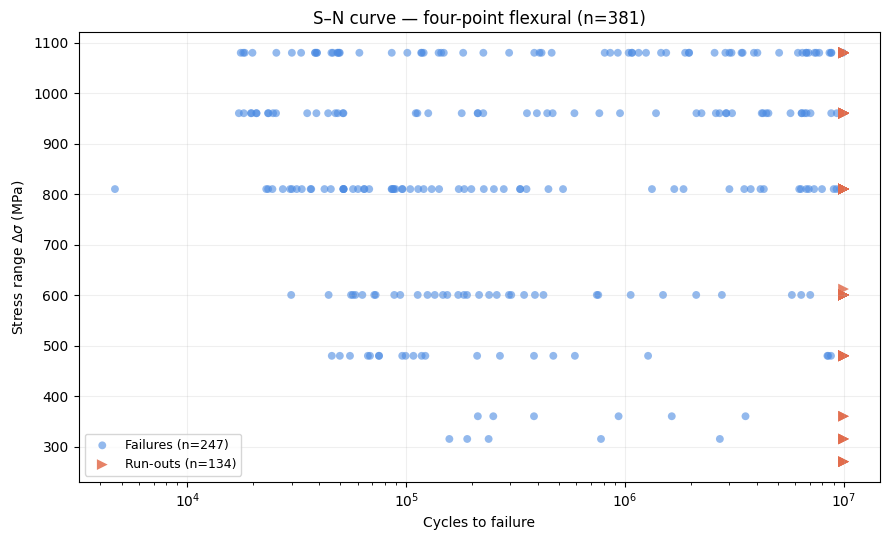

In [9]:
plot_data = tests.dropna(subset=["cycles", "deltaSigma"])
failures = plot_data[~plot_data["runout"]]
runouts = plot_data[plot_data["runout"]]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(failures["cycles"], failures["deltaSigma"], s=32, alpha=0.6, color=BLUE,
           label=f"Failures (n={len(failures)})", edgecolors="none")
if len(runouts):
    ax.scatter(runouts["cycles"], runouts["deltaSigma"], s=60, alpha=0.85, color=ORANGE,
               marker=">", label=f"Run-outs (n={len(runouts)})", edgecolors="none")

ax.set_xscale("log")
ax.set_xlabel("Cycles to failure")
ax.set_ylabel("Stress range $\\Delta\\sigma$ (MPa)")
ax.set_title(f"S–N curve — four-point flexural (n={len(plot_data):,})")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Specimen alignment

With load ratio constant, alignment is the one specimen-level factor that varies: 159 non-axial specimens against 34 axial. Build orientation drives fatigue anisotropy in powder-bed fusion, so this is the comparison worth making.

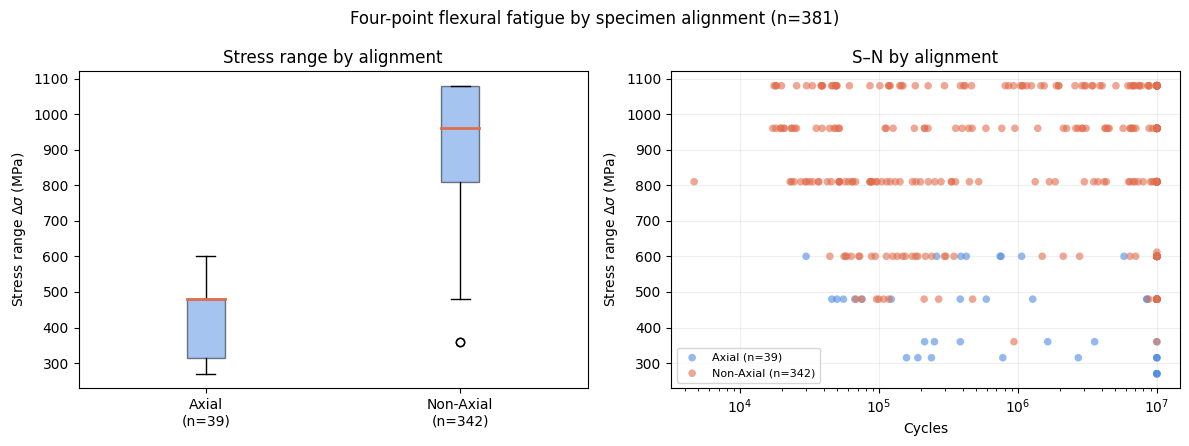

In [10]:
aligned = tests.merge(specimens[["uniqueId", "alignment"]], on="uniqueId", how="left")
aligned = aligned.dropna(subset=["alignment", "deltaSigma", "cycles"])
groups = sorted(aligned["alignment"].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].boxplot(
    [aligned.loc[aligned["alignment"] == g, "deltaSigma"] for g in groups],
    labels=[f"{g}\n(n={(aligned['alignment'] == g).sum()})" for g in groups],
    patch_artist=True,
    boxprops=dict(facecolor=BLUE, alpha=0.5),
    medianprops=dict(color=ORANGE, linewidth=2),
)
axes[0].set_ylabel("Stress range $\\Delta\\sigma$ (MPa)")
axes[0].set_title("Stress range by alignment")

for group, colour in zip(groups, (BLUE, ORANGE)):
    subset = aligned[aligned["alignment"] == group]
    axes[1].scatter(subset["cycles"], subset["deltaSigma"], s=30, alpha=0.6,
                    color=colour, label=f"{group} (n={len(subset)})", edgecolors="none")
axes[1].set_xscale("log")
axes[1].set_xlabel("Cycles")
axes[1].set_ylabel("Stress range $\\Delta\\sigma$ (MPa)")
axes[1].set_title("S–N by alignment")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

fig.suptitle(f"Four-point flexural fatigue by specimen alignment (n={len(aligned):,})")
plt.tight_layout()
plt.show()

## Retests

`retestNumber` is 0 for a first test and increments when a specimen is tested again — usually after a run-out, at a higher stress. Counting them shows how much of the dataset is repeat testing on already-cycled material.

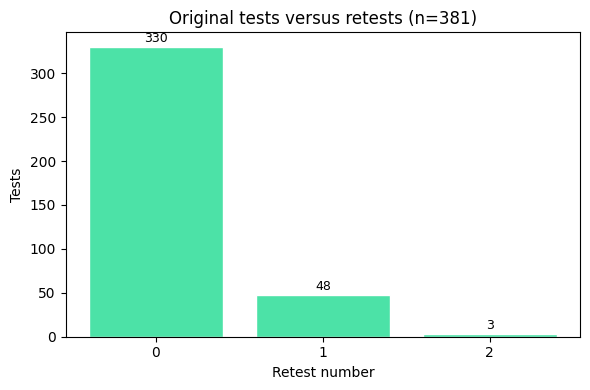

In [11]:
retest_counts = tests["retestNumber"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(retest_counts.index.astype(int).astype(str), retest_counts.values,
              color=GREEN, edgecolor="white")
for bar, value in zip(bars, retest_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f"{value:,}",
            ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Retest number")
ax.set_ylabel("Tests")
ax.set_title(f"Original tests versus retests (n={len(tests):,})")
plt.tight_layout()
plt.show()

Specimens carrying a retest have seen prior cycling, so their recorded life is not directly comparable with a virgin specimen's. Any model built on this data should either restrict to `retestNumber == 0` or carry the prior loading history as a feature.

## Summary by specimen alignment

In [12]:
merged = tests.merge(
    specimens[["uniqueId", "alignment", "b", "d", "l"]], on="uniqueId", how="left"
)

summary = (
    merged.groupby("alignment")
    .agg(
        tests=("cycles", "size"),
        median_cycles=("cycles", "median"),
        mean_deltaSigma=("deltaSigma", "mean"),
        runouts=("runout", "sum"),
    )
    .round(1)
)
summary

,tests,median_cycles,mean_deltaSigma,runouts
alignment,,,,
Axial,39,755827.0,430.7,10
Non-Axial,342,3040851.5,857.2,124
